### Generate original Mackey-Glass series


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as scipy_linalg
from scipy.special import ndtr

plt.rcdefaults()
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

def mackey_glass_derivative(x, x_tau, beta, gamma):
    return beta * x_tau / (1 + x_tau**10) - gamma * x

def runge_kutta4_step(x, x_tau, beta, gamma, dt):
    k1 = mackey_glass_derivative(x, x_tau, beta, gamma)
    k2 = mackey_glass_derivative(x + 0.5 * dt * k1, x_tau, beta, gamma)
    k3 = mackey_glass_derivative(x + 0.5 * dt * k2, x_tau, beta, gamma)
    k4 = mackey_glass_derivative(x + dt * k3, x_tau, beta, gamma)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def generate_mackey_glass_rk4(tau, beta, gamma, n, dt=1):
    mg_series = np.zeros(n)
    x = 1.2
    for i in range(n):
        x_tau = mg_series[max(0, i - tau)]
        x = runge_kutta4_step(x, x_tau, beta, gamma, dt)
        mg_series[i] = x
    return mg_series

def normalize(series, a, b):
    series_min, series_max = np.min(series), np.max(series)
    return a + ((series - series_min) / (series_max - series_min)) * (b - a)

tau, beta, gamma, n = 18, 0.2, 0.1, 5000
mg_series_rk4 = generate_mackey_glass_rk4(tau, beta, gamma, n)
mg_normalized = normalize(mg_series_rk4, 0, 1)



### Prediction performance of our laser reservoir system


In [2]:
# Prediction NRMSE for each predicted future step
laser_reservoir = np.array([0.07535968, 0.07654316, 0.07796828, 0.079532  , 0.08109658,
       0.08249487, 0.08358596, 0.08443798, 0.085461  , 0.08723551,
       0.09009996, 0.0924345 , 0.09448102, 0.09837375, 0.10405612,
       0.10868259, 0.11084949, 0.11242845, 0.11355823, 0.11432738,
       0.11476409, 0.11493129, 0.11503233, 0.11540294, 0.1163191 ,
       0.11777911, 0.11958961, 0.12174755, 0.12463165, 0.12870678])


### Load different nonlinearity functions

In [3]:
def stable_sigmoid(x):
    out = np.empty_like(x, dtype=np.float64)
    positive = x >= 0
    out[positive] = 1.0 / (1.0 + np.exp(-x[positive]))
    exp_x = np.exp(x[~positive])
    out[~positive] = exp_x / (1.0 + exp_x)
    return out


def softsign(x):
    x = np.asarray(x, dtype=np.float64)
    return x / (1.0 + np.abs(x))


def gaussian_rbf(x, gamma=1.0):
    x = np.asarray(x, dtype=np.float64)
    return np.exp(-gamma * x**2)


def sine_activation(x, omega=1.0):
    x = np.asarray(x, dtype=np.float64)
    return np.sin(omega * x)


def quadratic(x):
    x = np.asarray(x, dtype=np.float64)
    return x**2


def tanh_tunable(x, scale=1.0, shift=0.0):
    x = np.asarray(x, dtype=np.float64)
    return np.tanh(scale * x + shift)

### Load data preprocessing functions


In [4]:
def make_mvi_mask(n_variants, mask_seed):
    if n_variants < 1:
        raise ValueError("n_variants must be >= 1")
    if n_variants == 1:
        return np.ones(1, dtype=np.float64)
    rng = np.random.default_rng(mask_seed)
    return rng.uniform(0.0, 1.0, size=n_variants).astype(np.float64)


def add_awgn_per_variant(signal, snr_db, noise_seed=0, reference_stop=None):
    # Add additive white gaussian noise (AWGN) to each variant series
    signal = np.asarray(signal, dtype=np.float64)

    if signal.ndim != 2:
        raise ValueError("signal must have shape (time, n_variants)")
    
    if snr_db is None or np.isposinf(snr_db):
        return signal.copy(), np.zeros(signal.shape[1])
    
    reference = signal if reference_stop is None else signal[:reference_stop]

    if reference.size == 0:
        raise ValueError("The SNR reference interval must not be empty")
    
    signal_power = np.mean(reference ** 2, axis=0, keepdims=True)
    noise_std = np.sqrt(signal_power / (10.0 ** (snr_db / 10.0)))
    rng = np.random.default_rng(noise_seed)
    noisy_signal = signal + rng.normal(0.0, 1.0, size=signal.shape) * noise_std

    return noisy_signal, noise_std[0]


def prepare_noisy_variant_series(raw_series, n_variants, mask_seed, activation, snr_db, noise_seed, snr_reference_stop):
    mask = make_mvi_mask(n_variants, mask_seed)
    scaled_series = np.asarray(raw_series, dtype=np.float64)[:, None] * mask[None, :]
    noisy_scaled_series, noise_std = add_awgn_per_variant(scaled_series, snr_db, noise_seed=noise_seed, reference_stop=snr_reference_stop)

    return activation(noisy_scaled_series), mask, noise_std, scaled_series, noisy_scaled_series


def build_window_datasets(variant_series, N_train, N_test, lag_window):
    # Prepare input samples
    required_length = N_train + N_test + lag_window - 1
    if len(variant_series) < required_length:
        raise ValueError(f"variant_series needs at least {required_length} points")
    
    windows = np.lib.stride_tricks.sliding_window_view(variant_series, lag_window, axis=0)
    X_train = windows[:N_train].reshape(N_train, -1)
    X_test = windows[N_train:N_train + N_test].reshape(N_test, -1)

    return X_train, X_test


def build_Y(series, N_train, N_test, lag_window, future_step):
    # Prepare prediction target
    target_start = lag_window + future_step - 1
    Y_train = series[target_start:target_start + N_train]
    Y_test_start = N_train + target_start
    Y_test = series[Y_test_start:Y_test_start + N_test]

    if len(Y_train) != N_train or len(Y_test) != N_test:
        raise ValueError("Mackey-Glass series is too short for the requested prediction horizon")
    
    return Y_train, Y_test


def standardise_columns(x_train, x_test):
    # Training-set statistics only
    mean = x_train.mean(axis=0, keepdims=True)
    std = x_train.std(axis=0, keepdims=True)
    std = np.where(std > 1e-12, std, 1.0)

    return (x_train - mean) / std, (x_test - mean) / std


def fit_linear_readout(x_train, y_train, RIDGE_ALPHA):
    # One weight per feature, plus one output bias
    xa = np.column_stack([x_train, np.ones(len(x_train))]).astype(np.float64)
    gram, rhs = xa.T @ xa, xa.T @ y_train.astype(np.float64, copy=False)
    penalty = np.eye(gram.shape[0]) * RIDGE_ALPHA
    penalty[-1, -1] = 0.0
    
    return scipy_linalg.solve(gram + penalty, rhs, assume_a="pos", check_finite=False)


def compute_nrmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2) / np.var(y_true))


### Load main experiment and visualization functions


In [5]:
def run_nonlinear_experiment(series_clean, snr_db, RIDGE_ALPHA, N_train, N_test, lag_window, noise_seed_list, N_list, future_step_list, activation):

    # Run tanh models after adding noise to each variants
    test_errors = np.zeros((len(N_list), len(future_step_list), len(noise_seed_list)))
    train_input_stop = N_train + lag_window - 1

    for n_idx, N_value in enumerate(N_list):
        for s_idx, noise_seed in enumerate(noise_seed_list):

            activated_series, _, _, _, _ = prepare_noisy_variant_series(
                series_clean, N_value, mask_seed=0, activation=activation, snr_db=snr_db,
                noise_seed=noise_seed, snr_reference_stop=train_input_stop
            )

            X_train, X_test = build_window_datasets(activated_series, N_train, N_test, lag_window)
            X_train, X_test = standardise_columns(X_train, X_test)

            xa_test = np.column_stack([X_test, np.ones(len(X_test))])

            for h_idx, future_step in enumerate(future_step_list):

                Y_train, Y_test = build_Y(series_clean, N_train, N_test, lag_window, future_step)
                coefficients = fit_linear_readout(X_train, Y_train, RIDGE_ALPHA)
                Y_test_predict = xa_test @ coefficients

                test_errors[n_idx, h_idx, s_idx] = compute_nrmse(Y_test, Y_test_predict)

    ddof = 1 if len(noise_seed_list) > 1 else 0
    test_mean, test_std = test_errors.mean(axis=2), test_errors.std(axis=2, ddof=ddof)

    return test_mean, test_std


def plot_results(snr_db, error_mean, error_std, N_list, future_step_list, laser_reference):

    # Results visualizaiton
    font = 21
    plt.figure(figsize=(10, 7))

    for i, N_value in enumerate(N_list):
        y, yerr = error_mean[i], error_std[i]
        plt.plot(future_step_list, y, linewidth=2, label=f'Static tanh (N = {N_value}, {N_value*50} weights)')

    plt.plot(future_step_list, laser_reference, linewidth=2, marker='o', markersize=7, label='Laser reservoir', color='gray')

    title = 'Noiseless input' if snr_db is None or np.isposinf(snr_db) else f'SNR = {snr_db} dB'
    
    plt.title(title, fontsize=font, fontweight='bold')
    plt.xlabel('Predicted future step', fontsize=font)
    plt.ylabel('NRMSE', fontsize=font)
    plt.xticks(fontsize=font)
    plt.yticks(fontsize=font)
    plt.legend(frameon=0, fontsize=font-1, loc='upper left')
    plt.tight_layout()
    plt.show()



### Set parameters and run the experiment


- test different nonlinearity functions

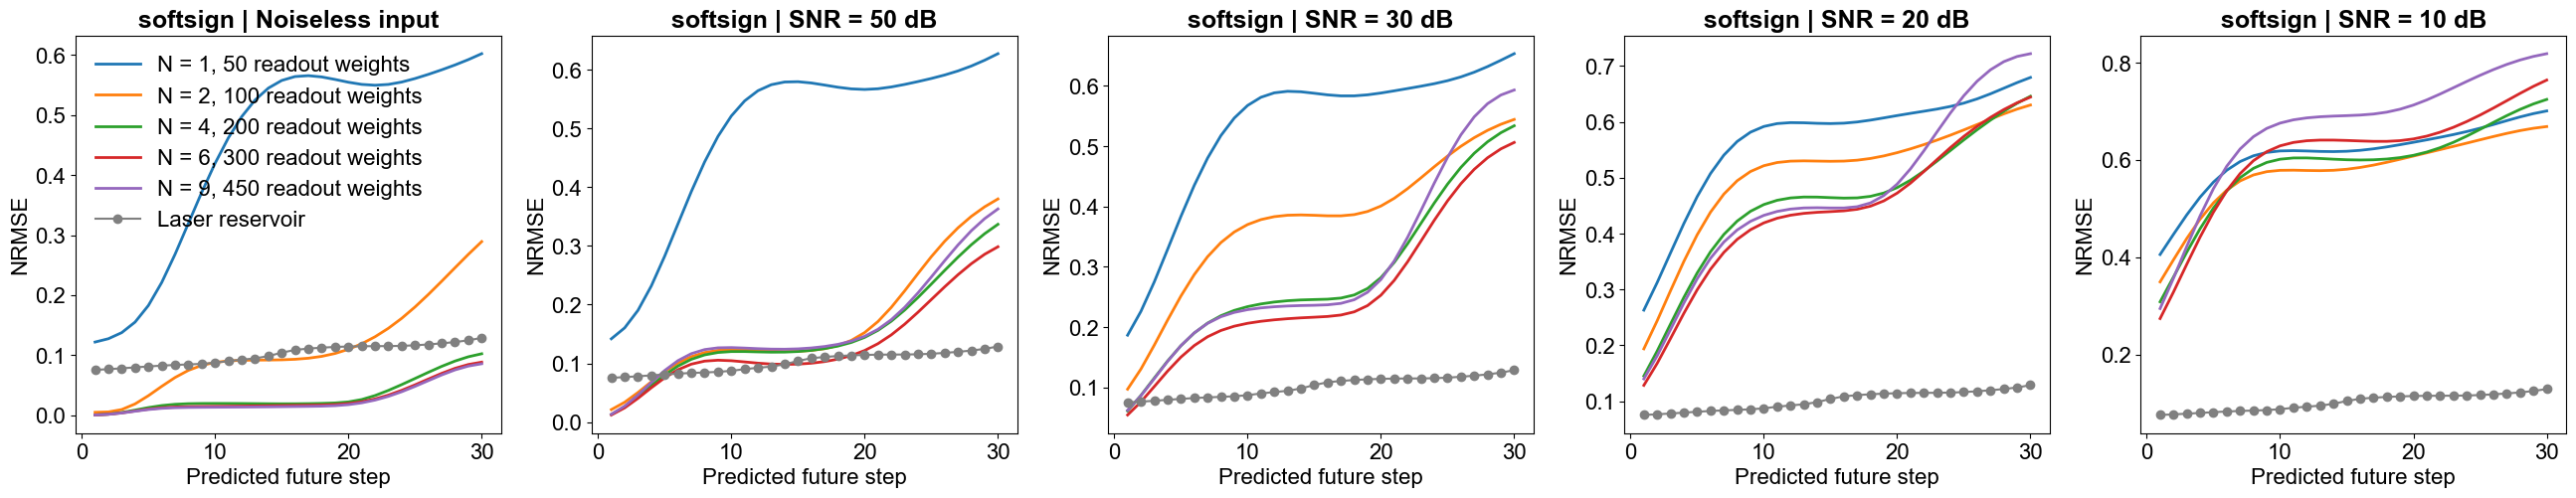

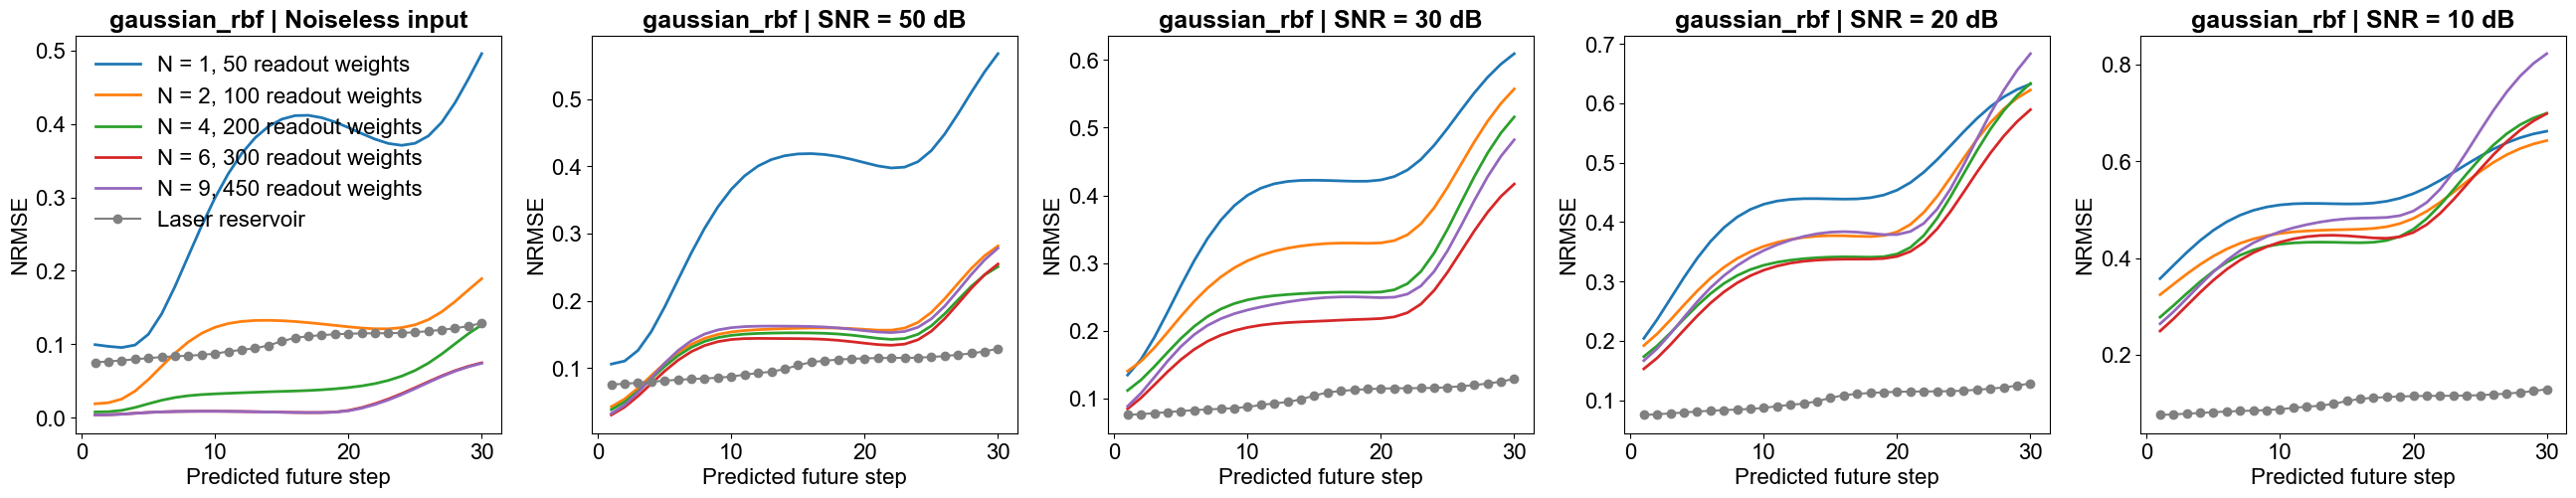

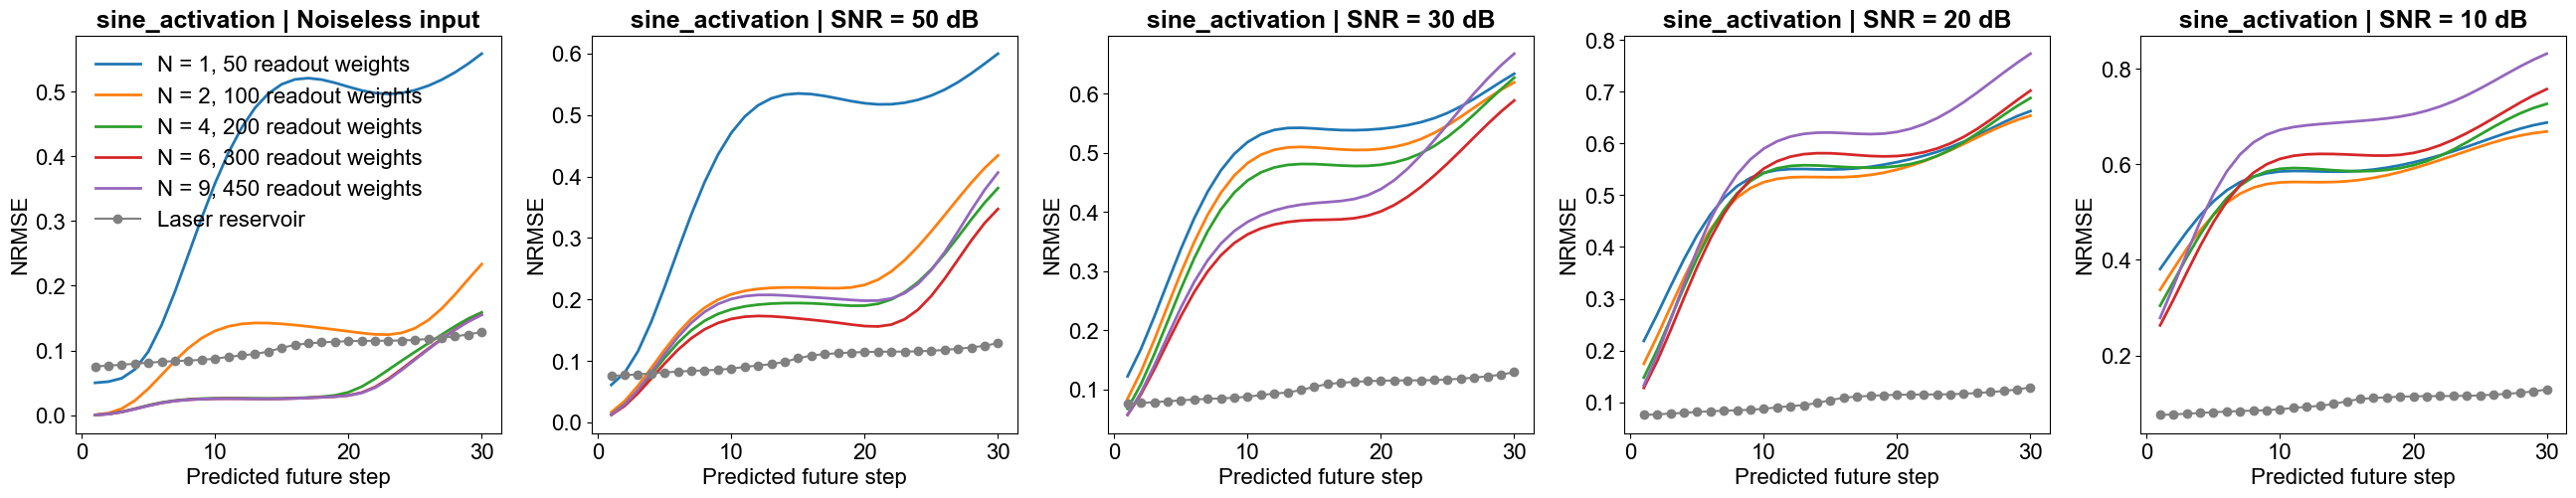

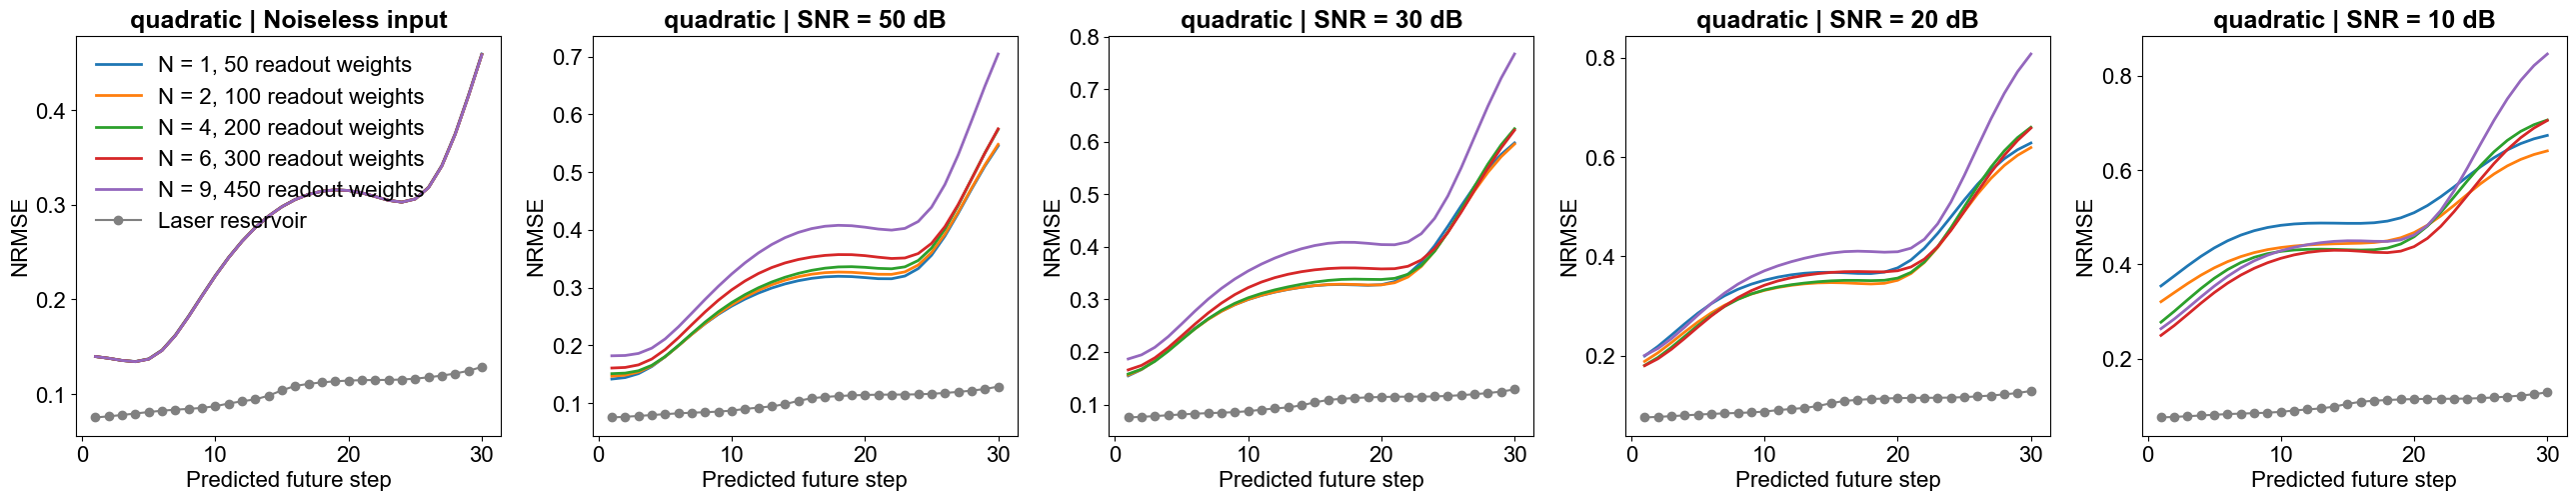

In [6]:
activation_functions = {
    'softsign': softsign,
    'gaussian_rbf': gaussian_rbf,
    'sine_activation': sine_activation,
    'quadratic': quadratic,
}

snr_values = [np.inf, 50, 30, 20, 10]

RIDGE_ALPHA = 1e-8
N_train, N_test, lag_window = 1200, 500, 50
noise_seed_list = [0, 1, 2, 3, 4]
N_list = [1, 2, 4, 6, 9]
future_step_list = np.arange(1, 31)

for activation_name, activation_fn in activation_functions.items():
    fig, axes = plt.subplots(1, len(snr_values), figsize=(26, 5.5), sharey=False)
    axes = np.atleast_1d(axes)

    for ax, snr_db in zip(axes, snr_values):
        test_mean, test_std = run_nonlinear_experiment(
            mg_normalized,
            snr_db,
            RIDGE_ALPHA,
            N_train,
            N_test,
            lag_window,
            noise_seed_list,
            N_list,
            future_step_list,
            activation_fn,
        )

        for i, N_value in enumerate(N_list):
            y = test_mean[i]
            yerr = test_std[i]
            ax.plot(future_step_list, y, linewidth=2, label=f'N = {N_value}, {N_value * 50} readout weights')

        ax.plot(future_step_list, laser_reservoir, marker='o', label='Laser reservoir', color='grey')
        ax.set_title(f'{activation_name} | Noiseless input' if np.isposinf(snr_db) else f'{activation_name} | SNR = {snr_db} dB', fontsize=18, fontweight='bold')
        ax.set_xlabel('Predicted future step', fontsize=16)
        ax.set_ylabel('NRMSE', fontsize=16)
        ax.tick_params(axis='both', labelsize=16)

    axes[0].legend(frameon=False, fontsize=16, loc='upper left')
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
    # plt.savefig(f'MG_static_{activation_name}.png', dpi=800, transparent=1)
